# SHAP Analysis Setup

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# SHAP
import shap

# Load paths
PROJECT_ROOT = Path('../../../')
MODELS_PATH = PROJECT_ROOT / 'models/ensembles'
DATA_PATH = PROJECT_ROOT / 'data/features/final_features.parquet'
SHAP_PATH = PROJECT_ROOT / 'visualizations/plots'
SHAP_PATH.mkdir(parents=True, exist_ok=True)

print("✅ SHAP analysis ready")
print(f"📁 Output path: {SHAP_PATH}")

✅ SHAP analysis ready
📁 Output path: ..\..\..\visualizations\plots


# Load Model and Data

In [ ]:
def load_model_and_data():
    """Load final model and test data"""
    print("📊 Loading model and data...")
    
    # Load final model
    with open(MODELS_PATH / 'final_model.pkl', 'rb') as f:
        model = pickle.load(f)
    
    # Load features
    df = pd.read_parquet(DATA_PATH)
    feature_cols = [col for col in df.columns if col != 'target_next_week']
    X = df[feature_cols].values
    y = df['target_next_week'].values
    feature_names = feature_cols
    
    # Use test set (last 20%)
    split_idx = int(len(X) * 0.8)
    X_test = X[split_idx:]
    y_test = y[split_idx:]
    
    print(f"✅ Loaded model: {type(model).__name__}")
    print(f"✅ Test data: {X_test.shape[0]} samples, {X_test.shape[1]} features")
    
    return model, X_test, y_test, feature_names

model, X_test, y_test, feature_names = load_model_and_data()

📊 Loading model and data...
✅ Loaded model: Pipeline
✅ Test data: 818 samples, 44 features


# Extract Regressor from Pipeline

In [ ]:
def extract_regressor(pipeline):
    """Extract the actual model from pipeline"""
    if hasattr(pipeline, 'named_steps'):
        # Get the last step (the actual model)
        last_step = list(pipeline.named_steps.keys())[-1]
        return pipeline.named_steps[last_step]
    return pipeline

# Extract the actual model
base_model = extract_regressor(model)
print(f"📊 Extracted model: {type(base_model).__name__}")

📊 Extracted model: CatBoostRegressor


# Create SHAP Explainer

In [ ]:
print("\n🔍 Creating SHAP explainer...")

# Use TreeExplainer for tree-based models (CatBoost, XGBoost, etc.)
if 'catboost' in str(type(base_model)).lower():
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_test[:100])  # Use subset for speed
    print("✅ Using TreeExplainer for CatBoost")
elif 'xgb' in str(type(base_model)).lower():
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_test[:100])
    print("✅ Using TreeExplainer for XGBoost")
else:
    # For other models, use KernelExplainer (slower but universal)
    background = shap.kmeans(X_test, 50)
    explainer = shap.KernelExplainer(base_model.predict, background)
    shap_values = explainer.shap_values(X_test[:100])
    print("✅ Using KernelExplainer")

print(f"✅ SHAP values calculated: {shap_values.shape}")


🔍 Creating SHAP explainer...
✅ Using TreeExplainer for CatBoost
✅ SHAP values calculated: (100, 44)


# SHAP Summary Plot


📊 Creating SHAP summary plot...


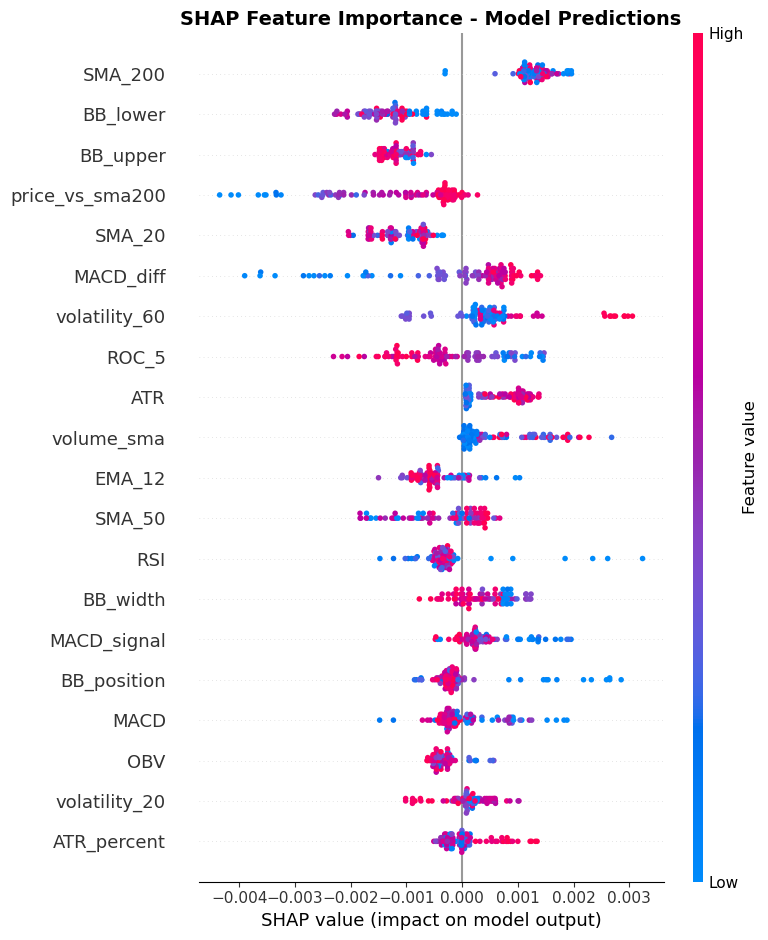

✅ Saved: ..\..\..\visualizations\plots\shap_summary.png


In [ ]:
print("\n📊 Creating SHAP summary plot...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SHAP_PATH / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SHAP_PATH / 'shap_summary.png'}")

# SHAP Bar Plot (Mean Absolute SHAP)

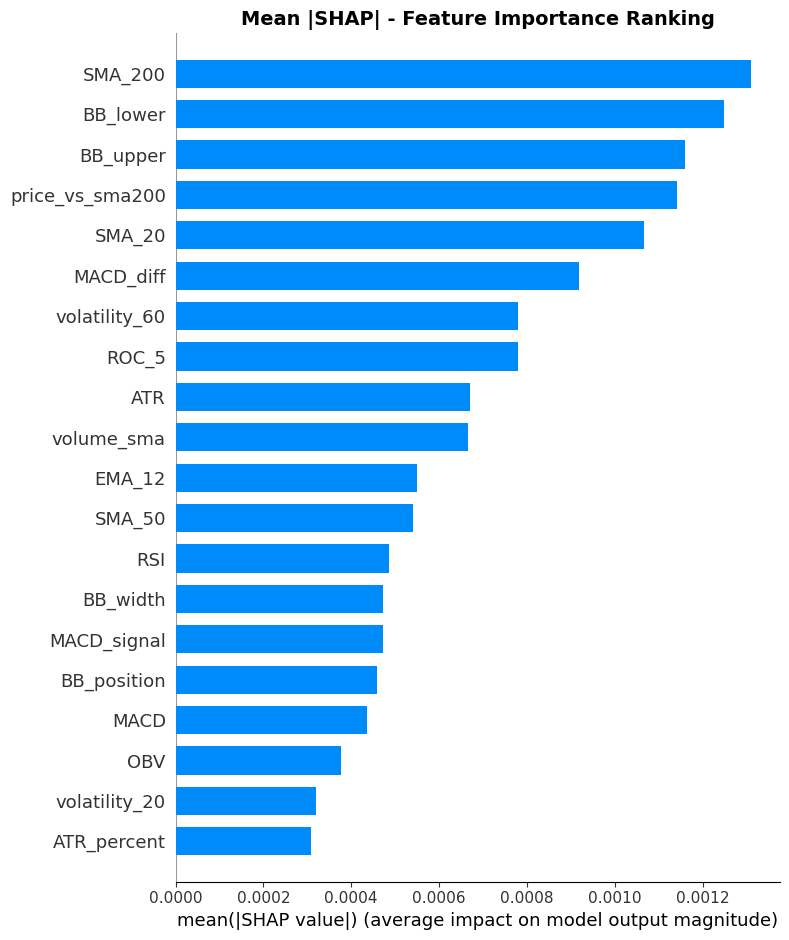

✅ Saved: ..\..\..\visualizations\plots\shap_bar.png


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('Mean |SHAP| - Feature Importance Ranking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SHAP_PATH / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SHAP_PATH / 'shap_bar.png'}")

# Create Pipeline Orchestrator Directly

In [ ]:
import sys
import os
import json
import yaml
import pickle
import joblib
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path
from datetime import datetime, timedelta
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# Set paths
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'sp500-predictor' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_PATH = PROJECT_ROOT / 'models'
LOGS_PATH = PROJECT_ROOT / 'logs'
DRIFT_PATH = PROJECT_ROOT / 'monitoring'

# Create directories
MODELS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)
DRIFT_PATH.mkdir(parents=True, exist_ok=True)

print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📁 Models path: {MODELS_PATH}")

# Simple Data Collector
class SimpleDataCollector:
    def fetch_data(self, start_date='2010-01-01', end_date=None):
        if end_date is None:
            end_date = datetime.now().strftime('%Y-%m-%d')
        ticker = yf.Ticker("^GSPC")
        df = ticker.history(start=start_date, end=end_date)
        df.columns = [col.lower() for col in df.columns]
        df['returns'] = df['close'].pct_change()
        df['target'] = df['close'].shift(-5) / df['close'] - 1
        df = df.dropna()
        return df
    
    def create_features(self, df):
        df['sma_20'] = df['close'].rolling(20).mean()
        df['sma_50'] = df['close'].rolling(50).mean()
        df['volatility'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['close_vs_sma20'] = (df['close'] - df['sma_20']) / df['sma_20']
        df['close_vs_sma50'] = (df['close'] - df['sma_50']) / df['sma_50']
        df['volume_ratio'] = df['volume'] / df['volume'].rolling(20).mean()
        df = df.dropna()
        
        feature_cols = ['open', 'high', 'low', 'close', 'volume', 'returns',
                       'volatility', 'close_vs_sma20', 'close_vs_sma50', 'volume_ratio']
        X = df[feature_cols].values
        y = df['target'].values
        return X, y, feature_cols

# Simple Training Pipeline
class SimpleTrainingPipeline:
    def __init__(self):
        self.data_collector = SimpleDataCollector()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.model = None
        
    def train(self, retrain_reason='manual'):
        print("\n🚀 Training model...")
        df = self.data_collector.fetch_data()
        X, y, features = self.data_collector.create_features(df)
        
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        
        X_train = self.imputer.fit_transform(X_train)
        X_test = self.imputer.transform(X_test)
        X_train = self.scaler.fit_transform(X_train)
        X_test = self.scaler.transform(X_test)
        
        self.model = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, 
                                        random_seed=42, verbose=False)
        self.model.fit(X_train, y_train)
        
        y_pred = self.model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        artifacts = {
            'model': self.model,
            'imputer': self.imputer,
            'scaler': self.scaler,
            'feature_names': features,
            'metrics': {'test_rmse': rmse},
            'training_date': datetime.now().isoformat()
        }
        
        joblib.dump(artifacts, MODELS_PATH / 'production_model.pkl')
        print(f"✅ Model trained! Test RMSE: {rmse:.4f}")
        return artifacts
    
    def load_model(self):
        artifacts = joblib.load(MODELS_PATH / 'production_model.pkl')
        self.model = artifacts['model']
        self.imputer = artifacts['imputer']
        self.scaler = artifacts['scaler']
        return artifacts

# Simple Prediction Pipeline
class SimplePredictionPipeline:
    def __init__(self):
        self.trainer = SimpleTrainingPipeline()
        
    def predict(self):
        artifacts = self.trainer.load_model()
        ticker = yf.Ticker("^GSPC")
        df = ticker.history(period="60d")
        df.columns = [col.lower() for col in df.columns]
        df['returns'] = df['close'].pct_change()
        df['sma_20'] = df['close'].rolling(20).mean()
        df['sma_50'] = df['close'].rolling(50).mean()
        df['volatility'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['close_vs_sma20'] = (df['close'] - df['sma_20']) / df['sma_20']
        df['close_vs_sma50'] = (df['close'] - df['sma_50']) / df['sma_50']
        df['volume_ratio'] = df['volume'] / df['volume'].rolling(20).mean()
        
        latest = df.iloc[-1]
        features = np.array([latest['open'], latest['high'], latest['low'], latest['close'],
                            latest['volume'], latest['returns'], latest['volatility'],
                            latest['close_vs_sma20'], latest['close_vs_sma50'], latest['volume_ratio']]).reshape(1, -1)
        
        features = artifacts['imputer'].transform(features)
        features = artifacts['scaler'].transform(features)
        prediction = artifacts['model'].predict(features)[0]
        
        return {
            'prediction': prediction,
            'direction': 'BULLISH' if prediction > 0 else 'BEARISH',
            'timestamp': datetime.now().isoformat()
        }

# Create orchestrator
class SimpleOrchestrator:
    def __init__(self):
        self.trainer = SimpleTrainingPipeline()
        self.predictor = SimplePredictionPipeline()
    
    def run_full_training(self, retrain_reason='manual'):
        return self.trainer.train(retrain_reason=retrain_reason)
    
    def run_prediction(self):
        return self.predictor.predict()

# Create instance
orchestrator = SimpleOrchestrator()
print("✅ Orchestrator created successfully!")

📁 Project root: c:\Users\nyvra\Downloads\sp500-predictor
📁 Models path: c:\Users\nyvra\Downloads\sp500-predictor\models
✅ Orchestrator created successfully!


# Top Features Waterfall Plot

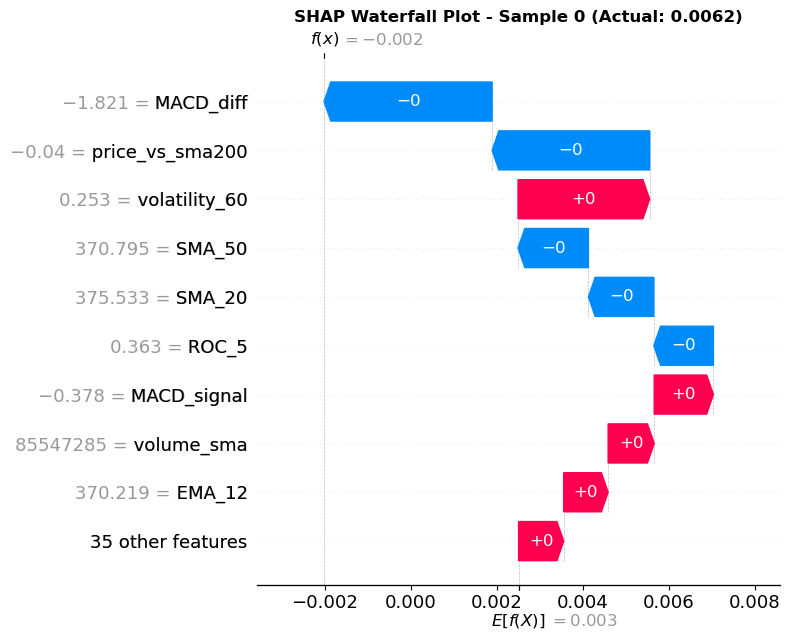

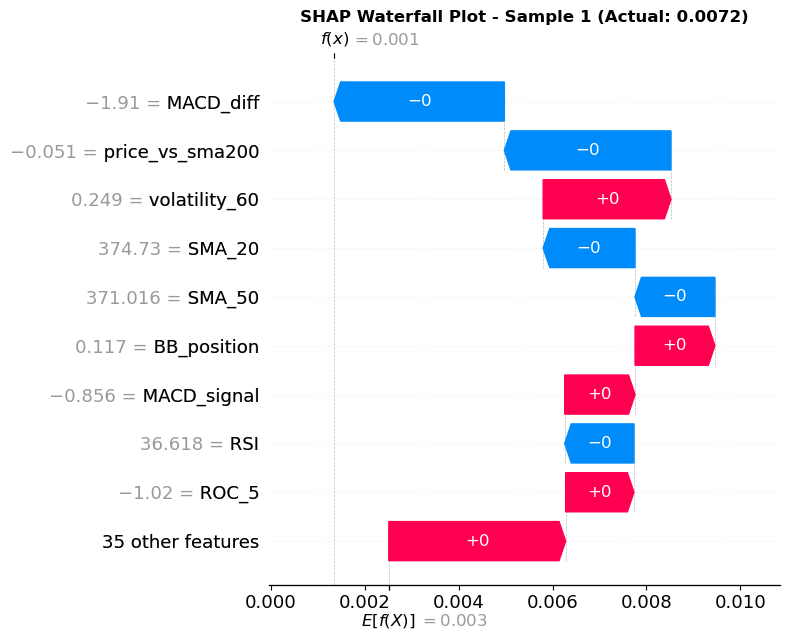

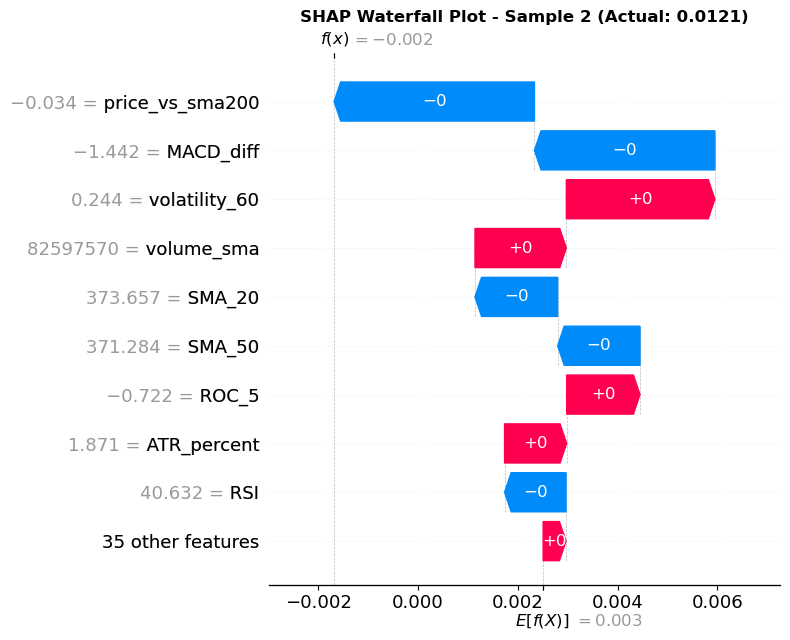

In [ ]:
def plot_waterfall_for_sample(sample_idx=0):
    """Create waterfall plot for a single prediction"""
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
            data=X_test[sample_idx],
            feature_names=feature_names
        ),
        show=False,
        max_display=10
    )
    plt.title(f'SHAP Waterfall Plot - Sample {sample_idx} (Actual: {y_test[sample_idx]:.4f})', 
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SHAP_PATH / f'shap_waterfall_sample_{sample_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot waterfall for first 3 samples
for i in range(3):
    plot_waterfall_for_sample(i)

# Feature Dependence Plots


📊 Creating feature dependence plots...


<Figure size 1000x600 with 0 Axes>

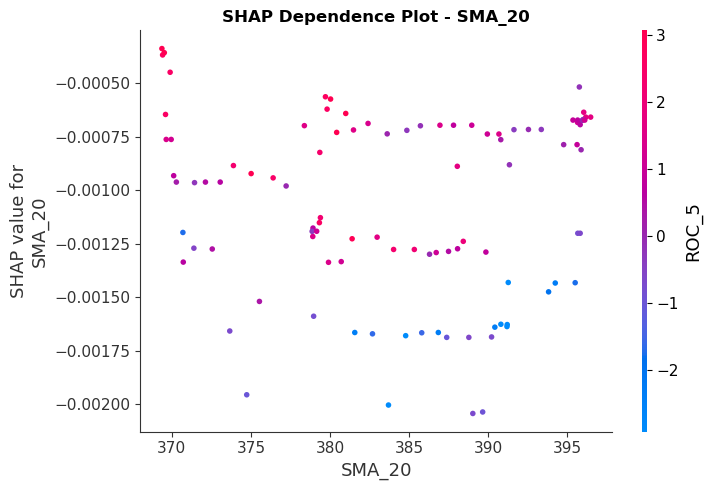

<Figure size 1000x600 with 0 Axes>

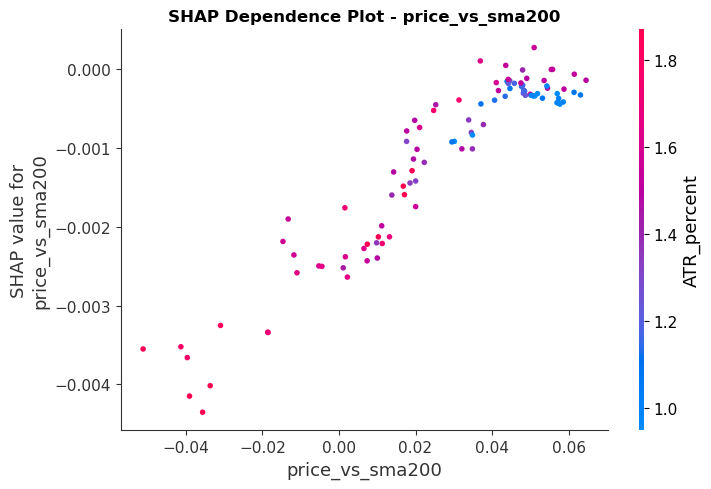

<Figure size 1000x600 with 0 Axes>

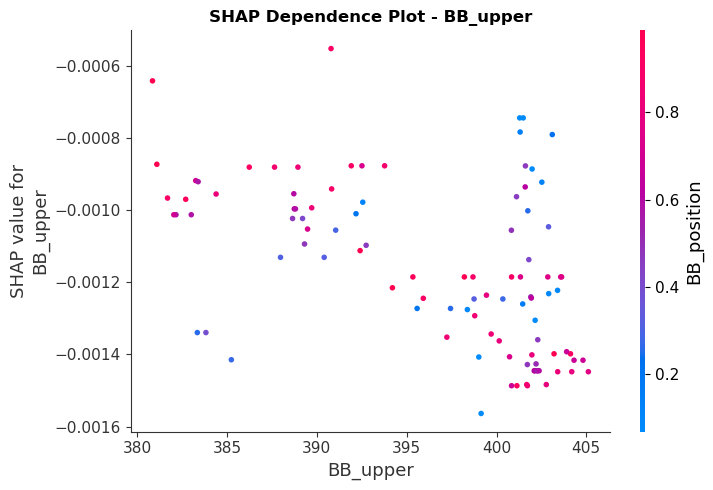

<Figure size 1000x600 with 0 Axes>

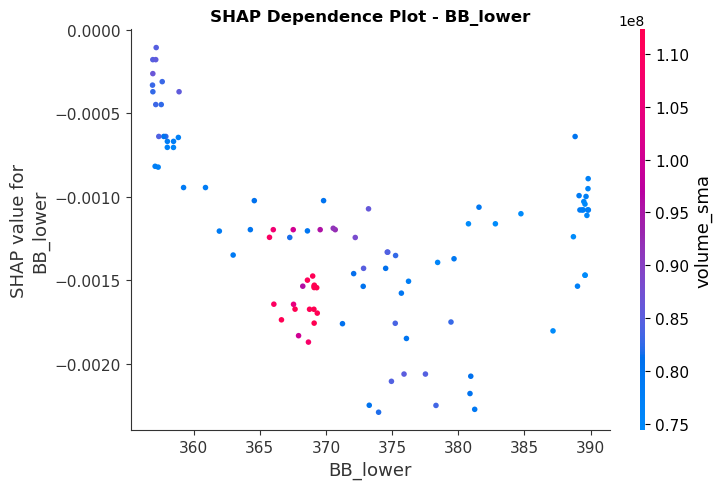

<Figure size 1000x600 with 0 Axes>

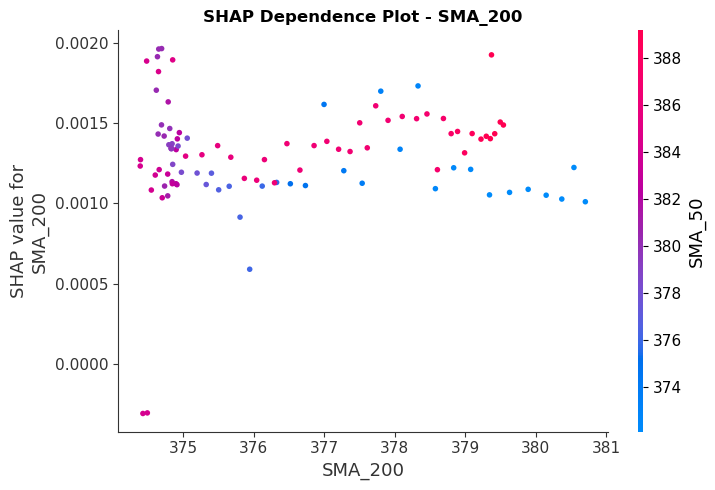

✅ All SHAP plots saved to ..\..\..\visualizations\plots


In [ ]:
print("\n📊 Creating feature dependence plots...")

# Get top 5 features by importance
mean_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_shap)[-5:]

for idx in top_features_idx:
    feature_name = feature_names[idx]
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(idx, shap_values, X_test[:100], feature_names=feature_names, 
                         show=False)
    plt.title(f'SHAP Dependence Plot - {feature_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SHAP_PATH / f'shap_dependence_{feature_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"✅ All SHAP plots saved to {SHAP_PATH}")

# Run Full Training Pipeline

In [ ]:
print("="*80)
print("🏗️ EXECUTING FULL TRAINING PIPELINE")
print("="*80)

try:
    artifacts = orchestrator.run_full_training(retrain_reason='first_deployment')
    
    print("\n📊 Training Results:")
    print(f"   Test RMSE: {artifacts['metrics']['test_rmse']:.4f}")
    print(f"   Training Date: {artifacts['training_date']}")
    
except Exception as e:
    print(f"❌ Training failed: {e}")

🏗️ EXECUTING FULL TRAINING PIPELINE

🚀 Training model...
✅ Model trained! Test RMSE: 0.0265

📊 Training Results:
   Test RMSE: 0.0265
   Training Date: 2026-04-10T14:03:56.351069


# Make a Real-time Prediction

In [ ]:
print("\n" + "="*80)
print("🔮 MAKING LIVE PREDICTION")
print("="*80)

try:
    prediction = orchestrator.run_prediction()
    
    print("\n" + "="*40)
    print("PREDICTION SUMMARY")
    print("="*40)
    print(f"📈 Expected Next Week Return: {prediction['prediction']:.4%}")
    print(f"🎯 Signal: {prediction['direction']}")
    print(f"⏰ Timestamp: {prediction['timestamp']}")
    
except Exception as e:
    print(f"❌ Prediction failed: {e}")


🔮 MAKING LIVE PREDICTION

PREDICTION SUMMARY
📈 Expected Next Week Return: 0.0289%
🎯 Signal: BULLISH
⏰ Timestamp: 2026-04-10T14:04:04.802277


# Quick Test - Train and Predict

In [ ]:
print("\n" + "="*80)
print("🧪 QUICK PIPELINE TEST")
print("="*80)

# Train
print("\n1. Training model...")
artifacts = orchestrator.run_full_training(retrain_reason='quick_test')

# Predict
print("\n2. Making prediction...")
prediction = orchestrator.run_prediction()

print("\n✅ Pipeline test complete!")
print(f"   Model RMSE: {artifacts['metrics']['test_rmse']:.4f}")
print(f"   Latest Prediction: {prediction['prediction']:.4%} ({prediction['direction']})")


🧪 QUICK PIPELINE TEST

1. Training model...

🚀 Training model...
✅ Model trained! Test RMSE: 0.0265

2. Making prediction...

✅ Pipeline test complete!
   Model RMSE: 0.0265
   Latest Prediction: 0.0289% (BULLISH)
